In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
#On charge les donnees

from src.data_loader import load_train, load_test

train = load_train()
test = load_test()

print("Train :", train.shape)
print("Test  :", test.shape)

Train : (1290081, 11)
Test  : (430100, 10)


In [8]:
train.head()

,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
0,dtf_0000001_ffa5beb5,0,op_05,636.75,acc_o_307358626ad66fed,87.00,-549.75,acc_d_7fac3b16af7d127b,630.88,1267.62,0
1,dtf_0000002_61992e82,0,op_05,636.12,acc_o_aeb690c57bf5d1de,76.93,76.93,acc_d_1d6120e8b117aa14,731.70,731.70,0
2,dtf_0000003_9a123b6d,0,op_05,681.00,acc_o_655c41913944d2b7,15943.74,15262.75,acc_d_ec2c21517a0ccb1a,758.83,1439.84,0
3,dtf_0000004_240f3dae,0,op_03,28175.40,acc_o_ba23a2b955a79a8b,-443.88,-28619.28,acc_d_a3dd8504815ec133,770924.84,799100.24,0
4,dtf_0000005_f18939e7,0,op_03,86429.15,acc_o_d05a23079bd066c1,-670.85,-87100.01,acc_d_0d4880267e62d5c4,91.13,86520.29,0


In [9]:
train.sample(5)

,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
39122,dtf_0039123_4f1e1814,5,op_05,746.04,acc_o_a74f6e1936399356,104.50,104.50,acc_d_c15e8979c5e182f0,629.19,629.19,0
182478,dtf_0182479_045d71b0,13,op_03,32016.01,acc_o_ac8f2739aca290db,70324.39,38308.38,acc_d_714de020fdf13831,105471.42,137487.43,0
961901,dtf_0961902_128a6fbb,67,op_03,23700.94,acc_o_00ba2e31622210f1,2860543.63,2836842.69,acc_d_f400798e4dd4a3d3,187092.26,210793.20,0
105357,dtf_0105358_a904b355,9,op_04,192019.02,acc_o_09d4b02dab504807,4.25,192023.25,acc_d_48f8450be9e858c6,6988.13,6988.13,0
594806,dtf_0594807_3d299ca7,38,op_05,741.63,acc_o_f88f04d276bc4cae,3553673.41,3552931.78,acc_d_107e15d25a3c38d6,24762.02,25503.65,0


In [10]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1290081 entries, 0 to 1290080
Data columns (total 11 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id                          1290081 non-null  str    
 1   period                      1290081 non-null  int64  
 2   operation                   1290081 non-null  str    
 3   amount                      1290081 non-null  float64
 4   origin_account              1290081 non-null  str    
 5   origin_balance_before       1290081 non-null  float64
 6   origin_balance_after        1290081 non-null  float64
 7   destination_account         1290081 non-null  str    
 8   destination_balance_before  1290081 non-null  float64
 9   destination_balance_after   1290081 non-null  float64
 10  fraud_flag                  1290081 non-null  int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 108.3 MB


In [11]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
period,1290081.0,4.463454e+01,2.946460e+01,0.00,18.00,40.00,68.00,105.00
amount,1290081.0,6.416038e+04,1.055554e+05,0.37,717.35,20506.16,87523.91,2526957.67
origin_balance_before,1290081.0,2.875629e+06,1.595036e+06,-235838.15,1766371.99,3127788.38,4031736.39,14439035.48
origin_balance_after,1290081.0,2.889497e+06,1.579518e+06,-235838.15,1803915.90,3134522.94,4030584.91,14439035.48
destination_balance_before,1290081.0,1.080057e+05,3.290812e+05,-233917.64,8662.11,55218.09,127411.94,14015520.35
destination_balance_after,1290081.0,1.242356e+05,3.727577e+05,-160051.49,23270.01,68299.76,135647.76,14228571.06
fraud_flag,1290081.0,1.004138e-01,3.005511e-01,0.00,0.00,0.00,0.00,1.00


In [13]:
#Les valeurs manquantes
missing = (
    train.isna()
         .sum()
         .sort_values(ascending=False)
)

missing[missing > 0]

Series([], dtype: int64)

In [14]:
train.duplicated().sum()

np.int64(0)

In [16]:
#Les desequilibres des classes
train["fraud_flag"].value_counts()

fraud_flag
0    1160539
1     129542
Name: count, dtype: int64

In [17]:
train["fraud_flag"].value_counts(normalize=True)

fraud_flag
0    0.899586
1    0.100414
Name: proportion, dtype: float64

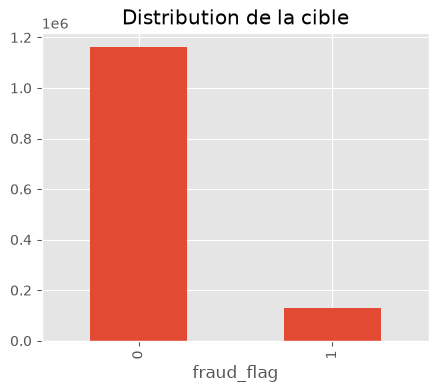

In [18]:
ax = train["fraud_flag"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Distribution de la cible")
plt.show()

In [19]:
#distribution des operations
train["operation"].value_counts()

operation
op_05    493352
op_03    415323
op_04    305443
op_02     71876
op_01      4087
Name: count, dtype: int64

In [20]:
#Les fraudes par operation
train.groupby("operation")["fraud_flag"].mean().sort_values(ascending=False)

operation
op_03    0.311907
op_01    0.000000
op_02    0.000000
op_04    0.000000
op_05    0.000000
Name: fraud_flag, dtype: float64

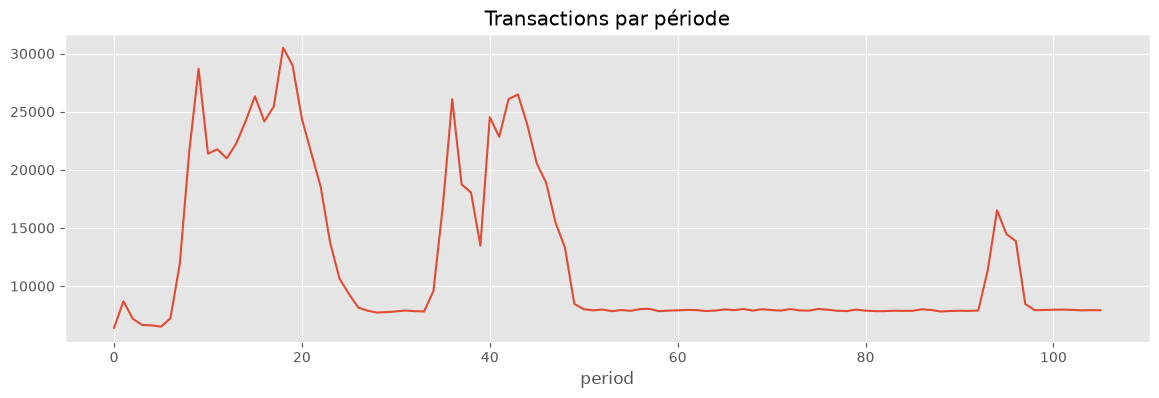

In [21]:
train["period"].value_counts().sort_index().plot(figsize=(14,4))
plt.title("Transactions par période")
plt.show()

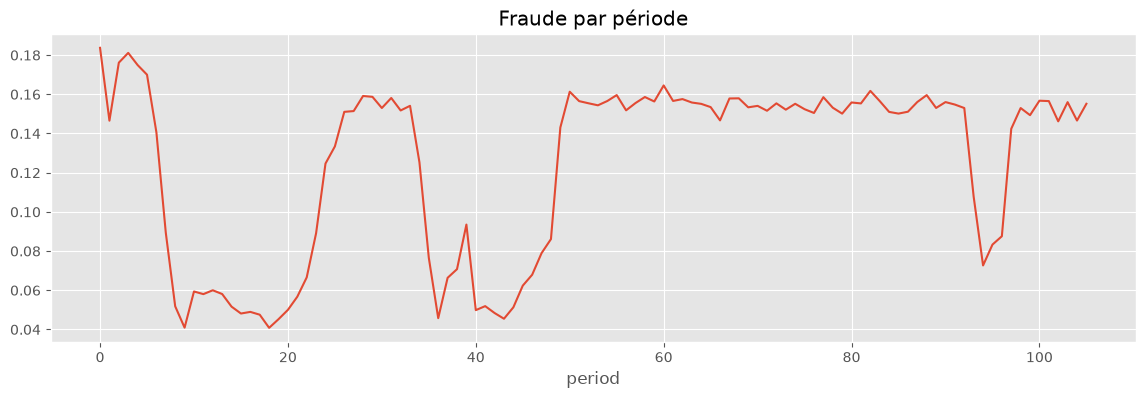

In [22]:
#Taux de fraudes par periode
fraud_by_period = (
    train
    .groupby("period")["fraud_flag"]
    .mean()
)

fraud_by_period.plot(figsize=(14,4))
plt.title("Fraude par période")
plt.show()

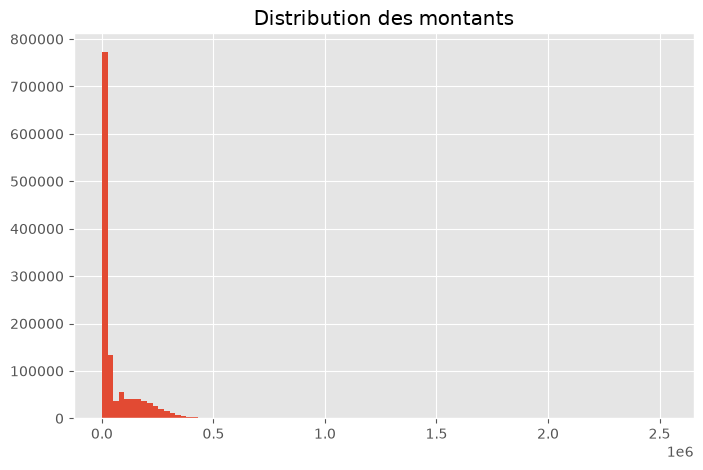

In [23]:
#distribution des montant
plt.figure(figsize=(8,5))
plt.hist(train["amount"], bins=100)
plt.title("Distribution des montants")
plt.show()

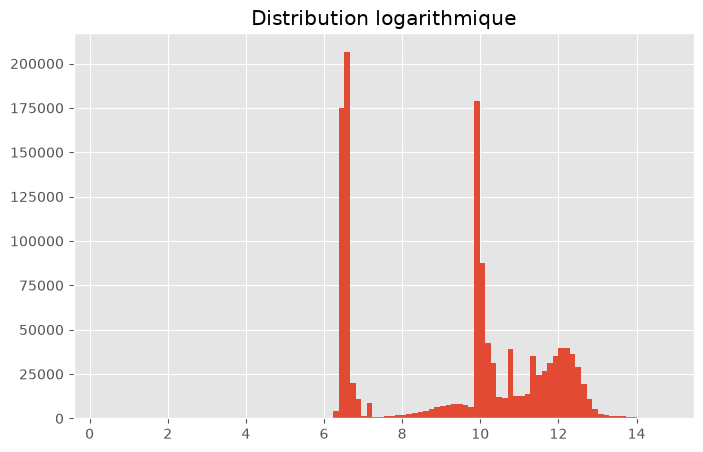

In [24]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(train["amount"]), bins=100)
plt.title("Distribution logarithmique")
plt.show()

In [25]:
numeric = train.select_dtypes(include="number")

numeric.corr()

,period,amount,origin_balance_before,origin_balance_after,destination_balance_before,destination_balance_after,fraud_flag
period,1.000000,-0.249103,0.179006,0.167576,0.084300,0.075905,0.089639
amount,-0.249103,1.000000,0.043319,0.047879,0.314669,0.381550,-0.107988
origin_balance_before,0.179006,0.043319,1.000000,0.997090,0.121097,0.124206,-0.043094
origin_balance_after,0.167576,0.047879,0.997090,1.000000,0.094502,0.091813,-0.052204
destination_balance_before,0.084300,0.314669,0.121097,0.094502,1.000000,0.987965,-0.047989
destination_balance_after,0.075905,0.381550,0.124206,0.091813,0.987965,1.000000,-0.032535
fraud_flag,0.089639,-0.107988,-0.043094,-0.052204,-0.047989,-0.032535,1.000000


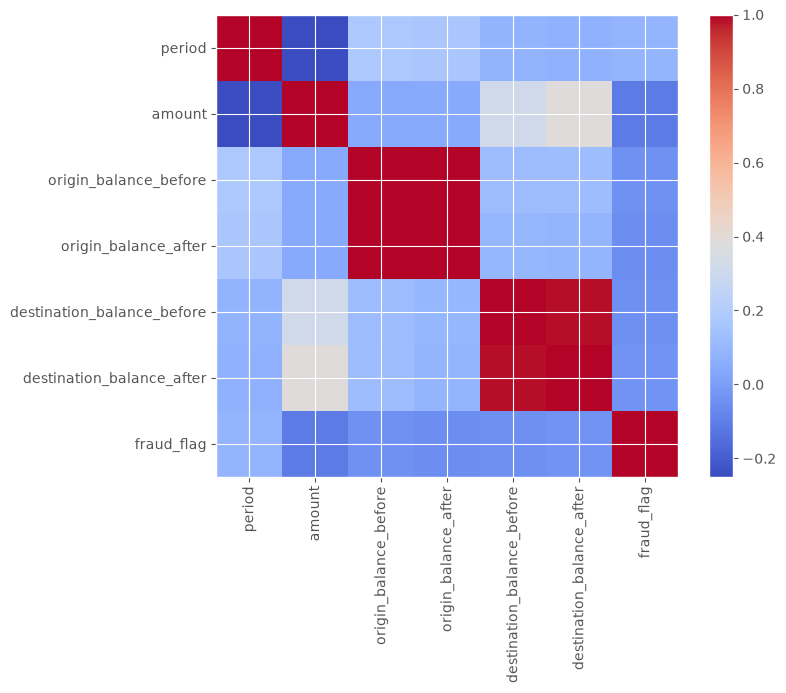

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(numeric.corr(), cmap="coolwarm")

plt.xticks(range(len(numeric.columns)), numeric.columns, rotation=90)

plt.yticks(range(len(numeric.columns)), numeric.columns)

plt.colorbar()

plt.show()